<a href="https://colab.research.google.com/github/fauziah-azzhr/PertemuanKeempat/blob/main/Pertemuan4LatihanPraktikum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving pert4.jpg to pert4 (1).jpg


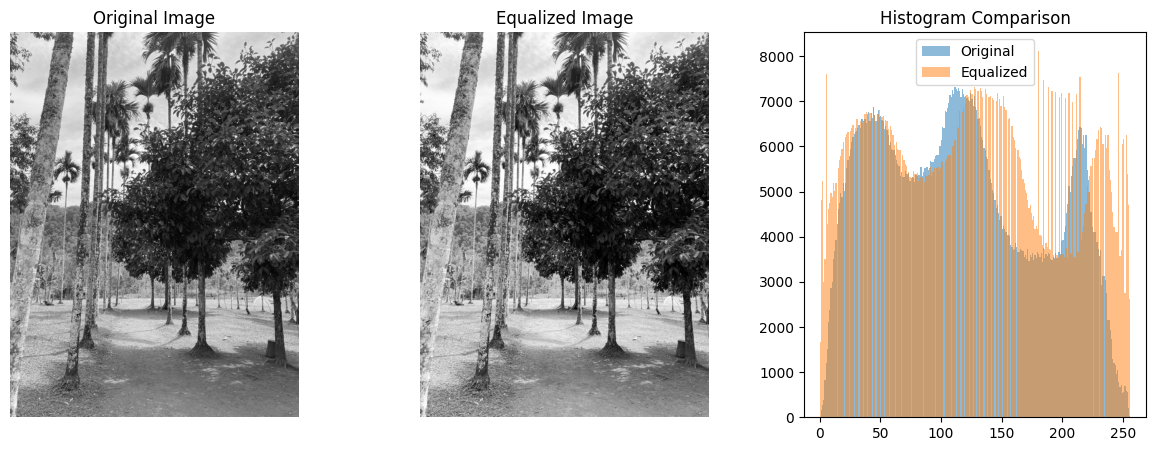

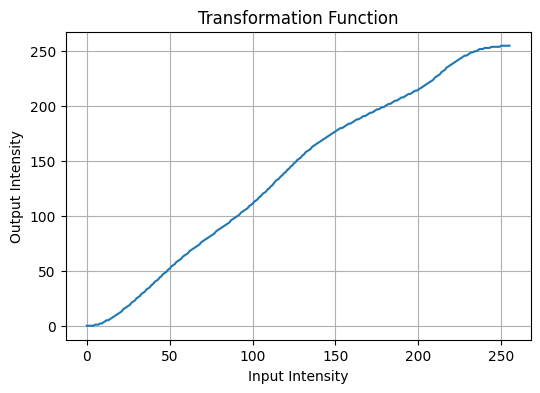

In [3]:
# ==========================================
# MANUAL HISTOGRAM EQUALIZATION
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image

# ==========================================
# 1. Upload Gambar
# ==========================================
uploaded = files.upload()

# Ambil nama file yang diupload
image_path = list(uploaded.keys())[0]

# Buka dan konversi ke grayscale
image = Image.open(image_path).convert('L')
image = np.array(image)

# ==========================================
# 2. Fungsi Manual Histogram Equalization
# ==========================================
def manual_histogram_equalization(image):
    """
    Manual implementation of histogram equalization

    Parameters:
    image: Input grayscale image (0-255)

    Returns:
    equalized_image: Hasil histogram equalization
    transformation_function: Fungsi transformasi (mapping 0-255)
    histogram: Histogram asli
    """

    # 1. Hitung histogram
    histogram = np.zeros(256, dtype=int)
    for pixel in image.flatten():
        histogram[pixel] += 1

    # 2. Hitung cumulative histogram (CDF)
    cumulative_histogram = np.zeros(256, dtype=int)
    cumulative_histogram[0] = histogram[0]
    for i in range(1, 256):
        cumulative_histogram[i] = cumulative_histogram[i-1] + histogram[i]

    # 3. Hitung transformation function
    total_pixels = image.shape[0] * image.shape[1]

    # Cari CDF minimum yang bukan nol
    cdf_min = cumulative_histogram[np.nonzero(cumulative_histogram)].min()

    transformation_function = np.zeros(256, dtype=np.uint8)
    for i in range(256):
        transformation_function[i] = round(
            (cumulative_histogram[i] - cdf_min) /
            (total_pixels - cdf_min) * 255
        )

    # 4. Apply transformation
    equalized_image = np.zeros_like(image, dtype=np.uint8)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            equalized_image[i, j] = transformation_function[image[i, j]]

    # 5. Return hasil
    return equalized_image, transformation_function, histogram

# ==========================================
# 3. Proses Histogram Equalization
# ==========================================
equalized_image, transformation_function, histogram = manual_histogram_equalization(image)

# ==========================================
# 4. Visualisasi Hasil
# ==========================================

plt.figure(figsize=(15,5))

# Gambar asli
plt.subplot(1,3,1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

# Gambar hasil equalization
plt.subplot(1,3,2)
plt.imshow(equalized_image, cmap='gray')
plt.title("Equalized Image")
plt.axis('off')

# Histogram sebelum dan sesudah
plt.subplot(1,3,3)
plt.hist(image.flatten(), bins=256, range=[0,256], alpha=0.5, label='Original')
plt.hist(equalized_image.flatten(), bins=256, range=[0,256], alpha=0.5, label='Equalized')
plt.title("Histogram Comparison")
plt.legend()

plt.show()

# ==========================================
# 5. Tampilkan Transformation Function
# ==========================================

plt.figure(figsize=(6,4))
plt.plot(transformation_function)
plt.title("Transformation Function")
plt.xlabel("Input Intensity")
plt.ylabel("Output Intensity")
plt.grid()
plt.show()

Saving lat2pert4.jpg to lat2pert4 (1).jpg


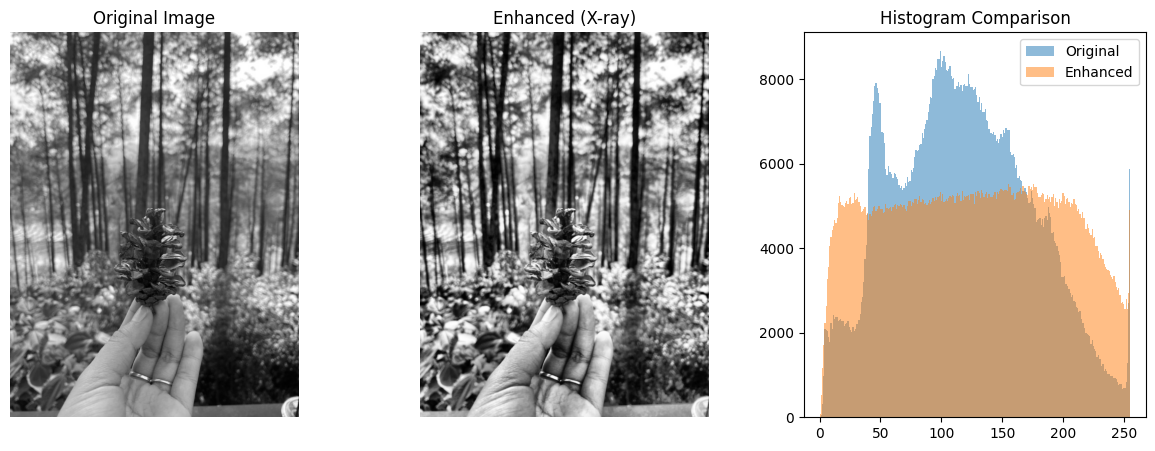

=== ENHANCEMENT REPORT ===
Contrast (Original): 56.44
Contrast (Enhanced): 69.36
Mean Intensity (Original): 117.72
Mean Intensity (Enhanced): 125.9
Estimated SNR: 1.03
Modality: X-ray


In [4]:
# ==========================================================
# MEDICAL IMAGE ENHANCEMENT PIPELINE
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image
import cv2

# ==========================================================
# 1. Upload Medical Image
# ==========================================================

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Load as grayscale
medical_image = Image.open(image_path).convert('L')
medical_image = np.array(medical_image)

# ==========================================================
# 2. Utility Functions
# ==========================================================

def calculate_metrics(original, enhanced):
    """Calculate enhancement quality metrics"""

    # Contrast (standard deviation)
    contrast_original = np.std(original)
    contrast_enhanced = np.std(enhanced)

    # Mean intensity
    mean_original = np.mean(original)
    mean_enhanced = np.mean(enhanced)

    # SNR estimation
    noise = enhanced - cv2.GaussianBlur(enhanced, (5,5), 0)
    snr = np.mean(enhanced) / (np.std(noise) + 1e-6)

    report = {
        "Contrast (Original)": round(float(contrast_original), 2),
        "Contrast (Enhanced)": round(float(contrast_enhanced), 2),
        "Mean Intensity (Original)": round(float(mean_original), 2),
        "Mean Intensity (Enhanced)": round(float(mean_enhanced), 2),
        "Estimated SNR": round(float(snr), 2)
    }

    return report


# ==========================================================
# 3. Main Enhancement Function
# ==========================================================

def medical_image_enhancement(medical_image, modality='X-ray'):
    """
    Adaptive enhancement for medical images

    Parameters:
    medical_image: Input medical image
    modality: 'X-ray', 'MRI', 'CT', 'Ultrasound'

    Returns:
    enhanced_image, enhancement_report
    """

    image = medical_image.copy()

    # Normalize image
    image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)
    image = image.astype(np.uint8)

    # ==========================================
    # MODALITY-SPECIFIC PIPELINE
    # ==========================================

    if modality == 'X-ray':
        # Improve contrast and bone structure visibility
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
        enhanced = clahe.apply(image)
        enhanced = cv2.GaussianBlur(enhanced, (3,3), 0)

    elif modality == 'MRI':
        # Noise reduction + soft tissue contrast preservation
        denoised = cv2.fastNlMeansDenoising(image, None, 10, 7, 21)
        enhanced = cv2.equalizeHist(denoised)

    elif modality == 'CT':
        # Sharpen edges (important for organ boundaries)
        blurred = cv2.GaussianBlur(image, (5,5), 0)
        enhanced = cv2.addWeighted(image, 1.5, blurred, -0.5, 0)

    elif modality == 'Ultrasound':
        # Reduce speckle noise
        median = cv2.medianBlur(image, 5)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        enhanced = clahe.apply(median)

    else:
        raise ValueError("Modality not supported. Choose: X-ray, MRI, CT, Ultrasound")

    # ==========================================
    # Generate Enhancement Report
    # ==========================================

    report = calculate_metrics(medical_image, enhanced)
    report["Modality"] = modality

    return enhanced, report


# ==========================================================
# 4. Run Enhancement
# ==========================================================

modality_choice = 'X-ray'  # Ganti sesuai kebutuhan

enhanced_image, enhancement_report = medical_image_enhancement(
    medical_image,
    modality=modality_choice
)

# ==========================================================
# 5. Visualize Results
# ==========================================================

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(medical_image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(enhanced_image, cmap='gray')
plt.title(f"Enhanced ({modality_choice})")
plt.axis('off')

plt.subplot(1,3,3)
plt.hist(medical_image.flatten(), bins=256, alpha=0.5, label='Original')
plt.hist(enhanced_image.flatten(), bins=256, alpha=0.5, label='Enhanced')
plt.title("Histogram Comparison")
plt.legend()

plt.show()

# ==========================================================
# 6. Print Enhancement Report
# ==========================================================

print("=== ENHANCEMENT REPORT ===")
for key, value in enhancement_report.items():
    print(f"{key}: {value}")

Processing Finished.


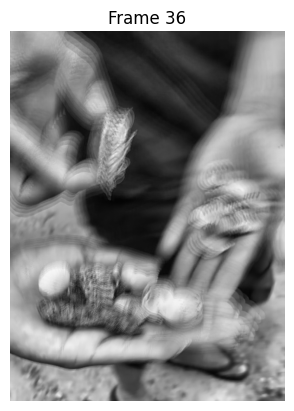

In [6]:
# ==========================================================
# REAL-TIME VIDEO ENHANCEMENT
# ==========================================================

import cv2
import numpy as np
import time
from collections import deque
from google.colab import files
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

# ==========================================================
# Real-Time Enhancement Class
# ==========================================================

class RealTimeEnhancement:
    def __init__(self, target_fps=30, buffer_size=5):
        self.target_fps = target_fps
        self.frame_time = 1.0 / target_fps
        self.history_buffer = deque(maxlen=buffer_size)  # memory limitation

    def enhance_frame(self, frame, enhancement_type='adaptive'):
        """
        Enhance single frame with real-time constraints

        Parameters:
        frame: Input video frame
        enhancement_type: Type of enhancement

        Returns:
        Enhanced frame
        """
        start_time = time.time()

        # Convert to grayscale for faster processing
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # ==========================================
        # Lightweight Enhancement Methods
        # ==========================================

        if enhancement_type == 'adaptive':
            # CLAHE (fast & effective)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            enhanced = clahe.apply(gray)

        elif enhancement_type == 'sharpen':
            blurred = cv2.GaussianBlur(gray, (3,3), 0)
            enhanced = cv2.addWeighted(gray, 1.5, blurred, -0.5, 0)

        elif enhancement_type == 'denoise':
            enhanced = cv2.fastNlMeansDenoising(gray, None, 10, 7, 21)

        else:
            enhanced = gray

        # ==========================================
        # Temporal Consistency
        # ==========================================

        self.history_buffer.append(enhanced)

        # Averaging with previous frames (reduce flicker)
        temporal_average = np.mean(self.history_buffer, axis=0).astype(np.uint8)

        # Convert back to BGR for display
        enhanced_bgr = cv2.cvtColor(temporal_average, cv2.COLOR_GRAY2BGR)

        # ==========================================
        # Maintain Target FPS
        # ==========================================

        processing_time = time.time() - start_time
        sleep_time = self.frame_time - processing_time

        if sleep_time > 0:
            time.sleep(sleep_time)

        return enhanced_bgr


# ==========================================================
# Upload Video File
# ==========================================================

print("Upload video file...")
uploaded = files.upload()
video_path = list(uploaded.keys())[0]

# ==========================================================
# Process Video Stream
# ==========================================================

cap = cv2.VideoCapture(video_path)

enhancer = RealTimeEnhancement(target_fps=30)

frame_count = 0
max_frames = 200  # Batasi agar Colab tidak berat

while cap.isOpened() and frame_count < max_frames:
    ret, frame = cap.read()

    if not ret:
        break

    enhanced_frame = enhancer.enhance_frame(frame, enhancement_type='adaptive')

    # Display using matplotlib (karena Colab tidak support cv2.imshow)
    plt.imshow(cv2.cvtColor(enhanced_frame, cv2.COLOR_BGR2RGB))
    plt.title(f"Frame {frame_count}")
    plt.axis('off')
    display(plt.gcf())
    clear_output(wait=True)

    frame_count += 1

cap.release()

print("Processing Finished.")